In [6]:
%load_ext autoreload
%autoreload 2

import json
import warnings 
from pathlib import Path
from collections import defaultdict
from typing import Optional
from functools import partial

from tqdm import tqdm

import jax
import jax.numpy as jnp
from jax import jit, hessian, grad, jacrev
jax.config.update("jax_enable_x64", True)

import numpy as np 
import pandas as pd

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from source.visuals import PARAMS, plot_mtx

from source.matrix_operations import khatri_rao_row

from source.evaluation import rmse, nll, norm_frob
from source.data_functions import get_batches, scale_data
from source.features import PPFeature, PPNFeature, RBFFeature, prepare_fmap
from source.general_functions import update_results_dict, extend_results_dict, create_dir_if_not_exists, query_df, check_nan
from source.optimization import adam_update, gd_update, full_grid

warnings.filterwarnings("ignore")
sns.set_theme()

DATA_DIR = Path('./data')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
def l2_reg_loss(w_vec, x, y, fmap, gamma_w, beta_e):
    scores = predict_score(w_vec, x, fmap)
    return 0.5*(beta_e*jnp.sum((y - scores)**2) + gamma_w*(w_vec * w_vec).sum())

def ls_sol(x, y, fmap, gamma_w, beta_e):
    alpha = gamma_w / beta_e
    F_mtx = get_design_mtx(x, fmap)
    A_mtx = F_mtx.T.conj().dot(F_mtx) + alpha*jnp.eye(F_mtx.shape[1])
    b = F_mtx.T.conj().dot(y)
    return jnp.linalg.solve(A_mtx, b)

def predict_score(w_vec, x, fmap):
    return jnp.real(get_design_mtx(x, fmap).dot(w_vec))

def cov_estimation(x, fmap, gamma_w, beta_e):
    F_mtx = get_design_mtx(x, fmap)
    hw_hand = beta_e*F_mtx.T.conj().dot(F_mtx) + gamma_w*jnp.eye(F_mtx.shape[1])
    w_cholesky = np.linalg.cholesky(hw_hand)
    w_cholesky = np.linalg.pinv(w_cholesky.T)
    w_cov = w_cholesky.dot(w_cholesky.T)
    return w_cov, w_cholesky, hw_hand

def w_sample(w_mean_vec, w_cholesky, seed=None):
    z = jnp.array(np.random.RandomState(seed).randn(w_mean_vec.size))
    return w_mean_vec + w_cholesky.dot(z)

def update_beta_e(c, d, w_cholesky, w_vec, fmap, x, y, n_samples=10):
    mean_train_err = 0.0
    for _ in range(n_samples):
        w_vec_sample = w_sample(w_vec, w_cholesky)
        scores = predict_score(w_vec_sample, x, fmap)
        mean_train_err += jnp.sum((y - scores)**2)
    mean_train_err /= n_samples
    c += 0.5 * x.shape[0]
    d += 0.5 * mean_train_err
    return c, d, c / max(d, 1e-8)

def update_gamma_w(a, b, w_cov, w_vec):
    w_cov_diag = w_cov if w_cov.ndim == 1 else w_cov.diagonal()
    a += 0.5 * w_vec.size
    b += 0.5 * ((w_vec * w_vec).sum() + w_cov_diag.sum())
    return a, b, a / max(b, 1e-8)

def get_design_mtx(x, fmap):
    design_mtx = fmap(x[:, 0], None)
    for k in range(1, x.shape[1]):
        design_mtx = khatri_rao_row(fmap(x[:, k], None), design_mtx)
    return design_mtx

def test_get_design_mtx():
    x = jnp.array([[1, 2, 3], [2, 3, 4], [3, 4, 5]])
    fmap, _ = prepare_fmap(PPFeature(), 2, False)

    actual = get_design_mtx(x, fmap)
    expected = jnp.array(
        [
            [1, 1, 2, 2, 3, 3, 6, 6], 
            [1, 2, 3, 6, 4, 8, 12, 24], 
            [1, 3, 4, 12, 5, 15, 20, 60],
        ]
    )
    print(jnp.linalg.norm(actual - expected))
test_get_design_mtx()

def adam_sol(w_vec, x, y, fmap, n_epoch, gamma_w, beta_e, grad_w, lr, bs):
    m = jnp.zeros_like(w_vec)
    v = jnp.zeros_like(m)
    t = 0  # Time step
    grad_norm_tracker, loss_tracker = list(), list()
    for ep in range(n_epoch):
        for x_batch, y_batch in get_batches(x, y, batch_size=bs):
            dw = grad_w(w_vec, x_batch, y_batch, fmap, gamma_w, beta_e)
            #w_vec = gd_update(w_vec, dw, lr)
            w_vec, m, v, t = adam_update(w_vec, dw, m, v, t, lr)
        loss_tracker.append((ep, l2_reg_loss(w_vec, x, y, fmap, gamma_w, beta_e).item()))
        grad_norm_tracker.append((ep, norm_frob(grad_w(w_vec, x, y, fmap, gamma_w, beta_e)).item()))
    return w_vec, grad_norm_tracker, loss_tracker

def bayes_lr(x, y, fmap, gamma_w, beta_e, n_epoch_global, beta_e_samples):
    beta_e_upd, gamma_w_upd = beta_e is None, gamma_w is None
    if beta_e_upd:
        cn, dn = 1, 1
        beta_e = cn / dn 
    if gamma_w_upd:
        an, bn = 1, 1
        gamma_w = an / bn
    loss = []
    for g_ep in range(n_epoch_global):
        # MAP Estimation:
        w_vec = ls_sol(x, y, fmap, gamma_w, beta_e)
        # Hessian Estimation:
        w_cov, w_cholesky, hw_hand = cov_estimation(x, fmap, gamma_w, beta_e)
        # Weights Precision:
        if gamma_w_upd: an, bn, gamma_w = update_gamma_w(an, bn, w_cov, w_vec)
        # Error Precision:
        if beta_e_upd: cn, dn, beta_e = update_beta_e(cn, dn, w_cholesky, w_vec, fmap, x, y, beta_e_samples)
        loss.append(l2_reg_loss(w_vec, x, y, fmap, gamma_w, beta_e))
    w_vec = ls_sol(x, y, fmap, gamma_w, beta_e)
    w_cov, w_cholesky, hw_hand = cov_estimation(x, fmap, gamma_w, beta_e)
    loss.append(l2_reg_loss(w_vec, x, y, fmap, gamma_w, beta_e))
    return w_vec, w_cov, w_cholesky, hw_hand, gamma_w, beta_e, loss

0.0


In [9]:
def generate_random_x(n_samples, d_dim, min_v=-4, max_v=4, seed=None):
    return np.random.RandomState(seed).uniform(min_v, max_v, (n_samples, d_dim))

def generate_model_data(n_samples, d_dim, m_order, fmap_tuple, std_err=1.0, min_v=-4, max_v=4, seed=None):
    x = generate_random_x(n_samples, d_dim, min_v, max_v, seed)
    x = jnp.array(scale_data(x, jnp.empty_like(x), [1], [1], True, False, 'std')[0])
    fmap, dtype = prepare_fmap(fmap_tuple, m_order, False)
    w_vec = np.random.RandomState(seed).randn(m_order**d_dim).astype(dtype)
    y_true = predict_score(w_vec, x, fmap)
    err = std_err*np.random.RandomState(seed).randn(n_samples)
    y = y_true + err
    return x, y, y_true, err, fmap, w_vec

In [10]:
def compute_behavior(w_vec, x, y, fmap, gamma_w, beta_e):
    # Loss:
    loss_val = l2_reg_loss(w_vec, x, y, fmap, gamma_w, beta_e)
    norm_w = norm_frob(w_vec)
    # Gradient:
    grad_w = grad(l2_reg_loss, argnums=0)
    norm_grad = norm_frob(grad_w(w_vec, x, y, fmap, gamma_w, beta_e))
    print(f'Loss={loss_val:.5f};')
    print(f'Norm(Grad)={norm_grad:.2e};')
    print(f'Norm(W)^2={norm_w**2:.5f};')
    print(f'RMSE={rmse(predict_score(w_vec, x, fmap), y):.2e}')

Theoretical(GT, gamma_w=0.0):
Loss=500.0;
Norm(Grad)=3.16e+02;

Ground Truth:
Loss=486.42290;
Norm(Grad)=3.67e+02;
Norm(W)^2=14.21457;
RMSE=9.82e-02

Variational Linear Regression:
Loss=490.94980;
Norm(Grad)=4.03e-11;
Norm(W)^2=14.28580;
RMSE=9.75e-02

True Beta=100; Est. Beta=102.383
Est. Gamma=0.631
Rel. Diff. Sol. = 1.53e-02
Full Hess.: Symm? True; Rank=9;


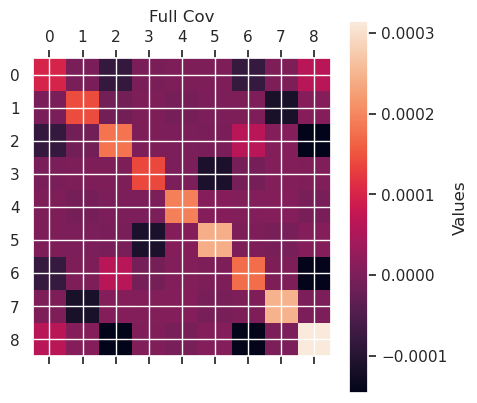

In [11]:
n_samples = 1000
d_dim = 2
m_order = 3
fmap_tuple = PPNFeature()
seed, beta_e = 1, 100

x, y, y_true, err, fmap, w_vec_true = generate_model_data(n_samples, d_dim, m_order, fmap_tuple, std_err=1/np.sqrt(beta_e), seed=seed)
F_mtx = get_design_mtx(x, fmap)
print(f'Theoretical(GT, gamma_w=0.0):\nLoss={n_samples/2};\nNorm(Grad)={np.sqrt(beta_e*jnp.linalg.trace(F_mtx.T.dot(F_mtx))):.2e};')
 
y_check = y
w_vec, w_cov, w_cholesky, hess_w, _gamma_w, _beta_e, loss = bayes_lr(x, y_check, fmap, None, None, 50, 5)

print('\nGround Truth:')
compute_behavior(w_vec_true, x, y_check, fmap, _gamma_w, beta_e)
print('\nVariational Linear Regression:')
compute_behavior(w_vec, x, y_check, fmap, _gamma_w, _beta_e)

print(f'\nTrue Beta={beta_e}; Est. Beta={_beta_e:.3f}')
print(f'Est. Gamma={_gamma_w:.3f}')
print(f'Rel. Diff. Sol. = {norm_frob(w_vec_true - w_vec) / norm_frob(w_vec_true):.2e}')
print(f'Full Hess.: Symm? {norm_frob(hess_w - hess_w.T) < 1e-10}; Rank={np.linalg.matrix_rank(hess_w)};')
plot_mtx(w_cov, title='Full Cov')

In [54]:
print(
    norm_frob(
        predict_score(w_vec, x, fmap) 
        - y_check
    )
)

print(
    norm_frob(
        predict_score(w_vec, x, fmap) 
        - y_check
    )
)

print(
    norm_frob(
        predict_score(w_sample(w_vec, w_cholesky), x, fmap) 
        - y_check
    )
)

3.0825911449563144
3.0825911449563144
3.0949889819623926
